# 09 — Evaluation, Confusion Matrix, Error Analysis, and Confidence

A trained ANN is not finished when the loss decreases. Evaluation asks **where** the model succeeds, where it fails, and how confident it is when failing.

Accuracy compresses all outcomes into one number. Experts inspect class-wise behavior and specific mistakes.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))

import tensorflow as tf
tf.random.set_seed(SEED)
model=tf.keras.Sequential([tf.keras.layers.Input((784,)),tf.keras.layers.Dense(64,activation='relu'),tf.keras.layers.Dense(10)])
opt=tf.keras.optimizers.Adam(1e-3); loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
ds=tf.data.Dataset.from_tensor_slices((X_train,y_train)).batch(128)
for _ in range(6):
    for xb,yb in ds:
        with tf.GradientTape() as tape: logits=model(xb,training=True); loss=loss_fn(yb,logits)
        grads=tape.gradient(loss,model.trainable_variables); opt.apply_gradients(zip(grads,model.trainable_variables))
logits=model(X_test,training=False); probs=tf.nn.softmax(logits,axis=1).numpy(); pred=probs.argmax(1)


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


2026-09-07 12:01:26.840876: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 12:01:26.867440: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-07 12:01:28.909249: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-09-07 12:01:29.167264: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-09-07 12:01:29.659870: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


              precision    recall  f1-score   support

           0      0.934     0.990     0.961       100
           1      0.952     0.990     0.971       100
           2      0.904     0.850     0.876       100
           3      0.845     0.930     0.886       100
           4      0.864     0.950     0.905       100
           5      0.883     0.830     0.856       100
           6      0.969     0.940     0.954       100
           7      0.854     0.880     0.867       100
           8      0.878     0.790     0.832       100
           9      0.902     0.830     0.865       100

    accuracy                          0.898      1000
   macro avg      0.899     0.898     0.897      1000
weighted avg      0.899     0.898     0.897      1000



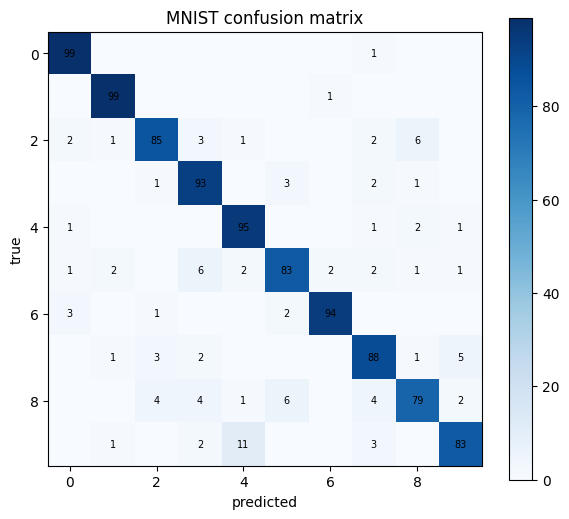

In [2]:
from sklearn.metrics import confusion_matrix, classification_report
cm=confusion_matrix(y_test,pred)
print(classification_report(y_test,pred,digits=3))
plt.figure(figsize=(7,6)); plt.imshow(cm,cmap='Blues'); plt.colorbar(); plt.xlabel('predicted'); plt.ylabel('true'); plt.title('MNIST confusion matrix')
for i in range(10):
    for j in range(10):
        if cm[i,j]>0: plt.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=7)
plt.show()


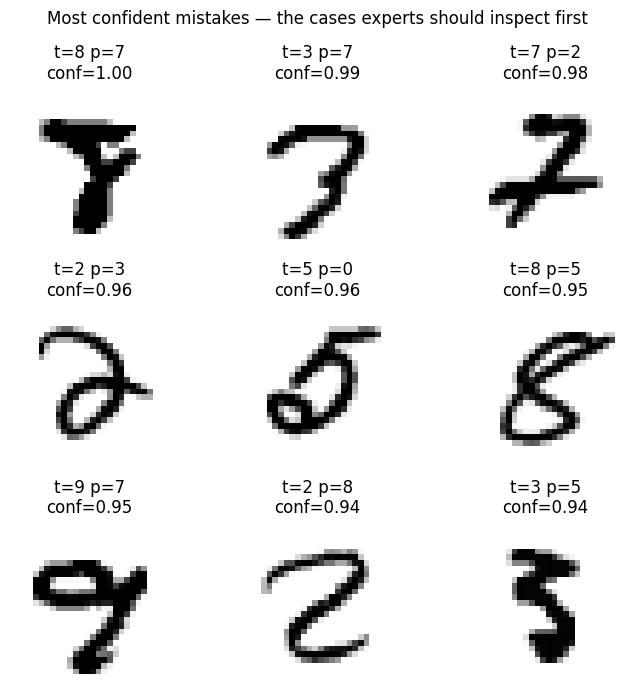

test accuracy: 0.898 mean confidence: 0.8659948


In [3]:
confidence=probs.max(1); wrong=np.flatnonzero(pred!=y_test)
order=wrong[np.argsort(-confidence[wrong])][:9] if len(wrong) else np.array([],dtype=int)
fig,axes=plt.subplots(3,3,figsize=(7,7))
for ax in axes.ravel(): ax.axis('off')
for ax,i in zip(axes.ravel(),order):
    ax.imshow(x_test[i],cmap='gray_r'); ax.set_title(f't={y_test[i]} p={pred[i]}\nconf={confidence[i]:.2f}'); ax.axis('off')
plt.suptitle('Most confident mistakes — the cases experts should inspect first')
plt.tight_layout(); plt.show()
print('test accuracy:', np.mean(pred==y_test), 'mean confidence:', confidence.mean())


## Production/business interpretation

High-confidence mistakes are more dangerous than uncertain mistakes when predictions trigger automatic actions. A fraud system, medical triage system, or quality-control system may need abstention thresholds, human review, calibration, or class-specific policies rather than a single argmax decision.

### Error analysis is a feedback loop

A confusion matrix tells you *which classes interact*. The image grid tells you *what those failures look like*. Confidence tells you *how certain the model was*. Those three views suggest different interventions: collect more examples for a confusing class pair, change preprocessing, increase capacity, add regularization, redesign the label taxonomy, or introduce human review for ambiguous cases.

### Segmentation matters

In enterprise deployments, always repeat evaluation by relevant slices: geography, device, channel, customer cohort, product family, time window, or other operating segment. Aggregate accuracy can look healthy while one commercially important segment performs badly. MNIST has no such business segmentation, but the analytical habit should be learned here.
